In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Load the data specifically for a single example JAL1 session

In [2]:
JAL1_SEQ3_tracking_data_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\fully_processed_tracking_data.pickle"
JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
with open(JAL1_SEQ3_tracking_data_file, "rb") as f:
    tracking_data = pickle.load(f)
video_df = pd.read_csv(JAL1_SEQ3_video_df)

In [3]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

Create a plot that shows head shelter angle by position sampling for a single JAL1 session

In [9]:
def generate_color_wheel(ax):
    angles = np.linspace(0, 2 * np.pi, 360)
    rgb_cycle = np.vstack((
        0.5 * (1.0 + np.cos(angles)),
        0.5 * (1.0 + np.cos(angles + 2 * np.pi / 3)),
        0.5 * (1.0 + np.cos(angles - 2 * np.pi / 3)),
    )).T

    angle_grid, radius_grid = np.meshgrid(angles, np.linspace(0, 1, 100))

    ax.pcolormesh(angle_grid, radius_grid, np.tile(rgb_cycle[:,0], (100,1)), 
                  color=rgb_cycle, shading='auto')

    ax.set_rticks([])
    ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
    ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '-135°', '-90°', '-45°'], fontsize=6)
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_title('Angle Legend', fontsize=8, pad=10)
    
    # Remove the box around the polar plot
    for spine in ax.spines.values():
        spine.set_visible(False)

def hsv_hdir_colormap(angles):
    phi = np.linspace(0, 2 * np.pi, 360)
    rgb_cycle = np.vstack((
        0.5 * (1.0 + np.cos(phi)),
        0.5 * (1.0 + np.cos(phi + 2 * np.pi / 3)),
        0.5 * (1.0 + np.cos(phi - 2 * np.pi / 3)),
    )).T
    bsa_rgb_cycle = np.zeros((len(angles), 3))
    for i in np.arange(360):
        bsa_rgb_cycle[angles == i + 1, :] = rgb_cycle[i, :]
    return bsa_rgb_cycle

def position_by_bsa(tracking_data, outofShelterIdx):
    mass = tracking_data["avg_loc"][outofShelterIdx, :]
    #ang_color = np.digitize(np.rad2deg(tracking_data["bod_shelt_dir"][outofShelterIdx]), np.arange(-180, 180))
    ang_color = np.digitize(np.rad2deg(tracking_data["hdir_shelt"][outofShelterIdx]), np.arange(-180, 180))
    bsa_rgb_cycle = hsv_hdir_colormap(ang_color)

    fig, (ax_main, ax_legend) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 1]}, figsize=(10,5))

    ax_main.scatter(mass[:, 0], mass[:, 1], s=5, c=bsa_rgb_cycle, linewidths=0, marker=".")
    ax_main.set_title("Position coloured by angle to shelter")
    ax_main.invert_yaxis()
    ax_main.set_aspect("equal")
    ax_main.axis('off')
    
    ax_legend = plt.subplot(1, 2, 2, projection='polar')
    ax_legend.set_frame_on(False)
    generate_color_wheel(ax_legend)
    ax_legend.patch.set_alpha(0)

    # set the ax_legend spines for the box to be invisible
    ax_legend.set_yticklabels([])
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure as eps
    fig.savefig(os.path.join(save_path, "position_by_hsa_colour_wheel.eps"), format='eps', bbox_inches='tight', dpi=300)

In [8]:
tracking_data.keys()

dict_keys(['avg_loc', 'neck_loc', 'upper_body_loc', 'lower_body_loc', 'head_loc', 'body_loc', 'hdir', 'shelter_loc', 'bod_shelt_dir', 'hdir_shelt', 'barrier_loc', 'hdir_barrier', 'randP_loc', 'hdir_randP', 'avg_Velocity', 'distance rel. to shelter', 'speed rel. to shelter', 'bodyparts'])

I couldn't figure out how to get rid of the box around the colour wheel so I deleted it in illustrator, tried for a bit, quicker to just do it in adobe

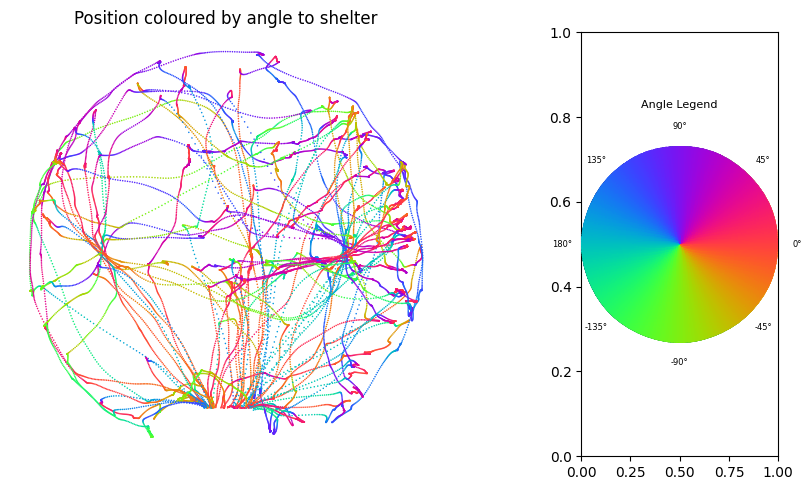

In [10]:
position_by_bsa(tracking_data=tracking_data, outofShelterIdx=np.array(video_df["OutofshelterIdx"].to_numpy()))

In [6]:
def position_by_bsa_grey(tracking_data, outofShelterIdx):
    mass = tracking_data["avg_loc"][outofShelterIdx, :]

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot all positions in grey
    ax.scatter(mass[:, 0], mass[:, 1], s=5, c='grey', linewidths=0, marker=".", alpha=1)
    ax.set_title("Single Session Coverage Example", fontsize=18)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure as eps
    fig.savefig(os.path.join(save_path, "single_session_coverage.eps"), format='eps', bbox_inches='tight', dpi=300)

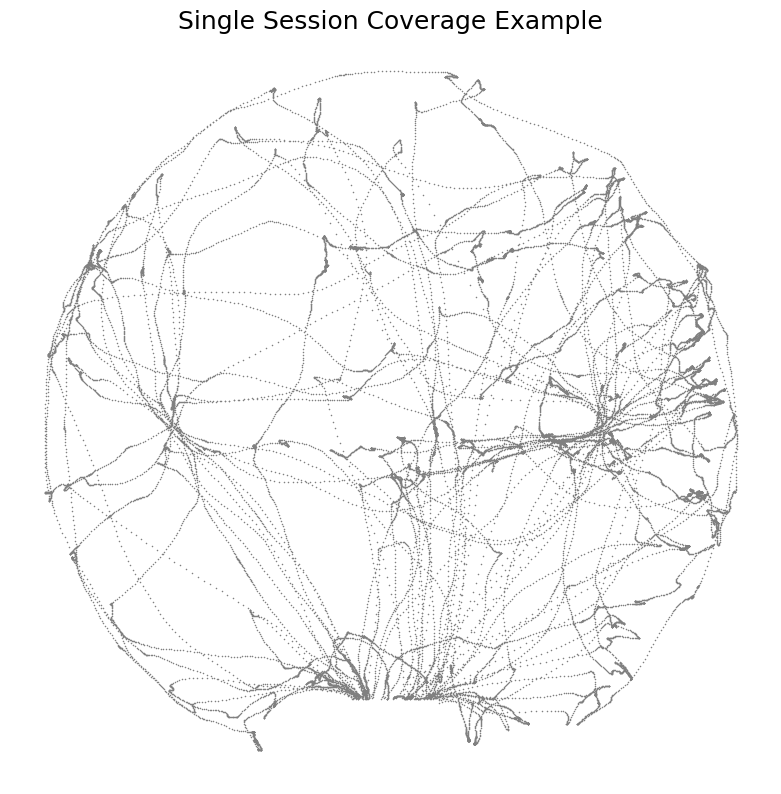

In [7]:
position_by_bsa_grey(tracking_data=tracking_data, outofShelterIdx=np.array(video_df["OutofshelterIdx"].to_numpy()))